# The Nearest Correlation Matrix as a Semidefinite Program

## Problem

A symmetric matrix $A\in\mathbb R^{n\times n}$ estimated from real data — pairwise correlations
computed on overlapping but non-identical date ranges (asynchronous or missing observations across
assets), or a stress-test correlation matrix with a subset of entries manually overridden by a risk
desk — need not be a valid correlation matrix. It has unit diagonal by construction, but nothing
forces $A\succeq 0$ (positive semidefinite): pairwise-complete correlation estimation only enforces
each $2\times2$ principal submatrix to be a valid correlation block, which does not imply the full
$n\times n$ matrix is PSD. An indefinite "correlation matrix" is not a modeling inconvenience — it
implies a portfolio with *negative* variance under the stated correlations, and will silently
corrupt any downstream Cholesky factorization, Monte Carlo sampler, or risk decomposition that
assumes $A\succeq 0$.

The correction problem, following Higham (2002), *Computing the Nearest Correlation Matrix — A
Problem from Finance*, is to find the valid correlation matrix closest to $A$ in Frobenius norm:
$$
\min_{X\in\mathbb R^{n\times n}} \ \|X-A\|_F \quad\text{s.t.}\quad X\succeq 0,\ \ \mathrm{diag}(X)=1,\ \ X=X^\top.
$$
The feasible set is the intersection of the positive-semidefinite cone $\mathcal S=\{X\succeq0\}$
(a convex cone, not a linear subspace) with the affine subspace $\mathcal U=\{X:X=X^\top,\
\mathrm{diag}(X)=1\}$ — this is exactly the standard form of a semidefinite program: a convex
quadratic objective over the intersection of an affine set with the PSD cone.

## Method

**Projection onto each set separately is cheap.** The Frobenius-norm projection of a symmetric
matrix $Y$ onto the PSD cone $\mathcal S$ is given in closed form by its eigendecomposition:
writing $Y=Q\Lambda Q^\top$ with $\Lambda=\mathrm{diag}(\lambda_1,\dots,\lambda_n)$, the nearest
PSD matrix is
$$
P_{\mathcal S}(Y) = Q\,\Lambda^+\,Q^\top,\qquad \Lambda^+=\mathrm{diag}(\max(\lambda_i,0)),
$$
i.e. clip every negative eigenvalue to zero and reassemble — this is the matrix analogue of
projecting a real number onto $[0,\infty)$, and it is a projection precisely because the Frobenius
norm is unitarily invariant, so $\|Y-X\|_F^2=\sum_i(\lambda_i(Y)-\lambda_i(X))^2$ for any $X$
diagonalized in the *same* eigenbasis, and no other eigenbasis can do better once $Y$'s own
eigenbasis is used. The projection onto the affine constraint set $\mathcal U$ is even simpler:
since $\mathcal U$ only fixes the diagonal, $P_{\mathcal U}(Y)$ replaces $Y$'s diagonal with all
ones and leaves the off-diagonal entries untouched.

**Why naive alternating projection is not enough.** A first instinct is to alternate: project onto
$\mathcal S$, then onto $\mathcal U$, repeat. This is the classical Cheney-Goldstein / von Neumann
alternating-projection scheme, and for two convex sets with nonempty intersection it *does*
converge to a point in $\mathcal S\cap\mathcal U$ — but not, in general, to the point of
$\mathcal S\cap\mathcal U$ nearest to the original $A$. The reason is that plain alternating
projection has no memory of $A$ once the first projection is taken: after computing
$X_0=P_{\mathcal S}(A)$, the second projection $P_{\mathcal U}(X_0)$ is the nearest point in
$\mathcal U$ *to $X_0$*, not to $A$, and each subsequent step compounds this drift. The iterates
converge to *some* feasible point, but the sequence of intermediate targets has permanently lost
the information needed to certify Frobenius-optimality against $A$.

**Dykstra's correction.** Dykstra's algorithm (Dykstra 1983; Boyle & Dykstra 1986) fixes this by
keeping a correction term $\Delta S$ that records how much the previous PSD projection had to move
its input, and *subtracts that same correction back out* before the next PSD projection is
attempted — so each projection is always applied to a point that has been "de-biased" by the
memory of the last correction, rather than to the raw output of the previous step:
$$
\begin{aligned}
Y_0 &= A, \quad \Delta S_0 = 0\\
R_k &= Y_k - \Delta S_k\\
X_k &= P_{\mathcal S}(R_k)\\
\Delta S_{k+1} &= X_k - R_k\\
Y_{k+1} &= P_{\mathcal U}(X_k)
\end{aligned}
$$
Boyle & Dykstra (1986) prove this converges to the exact Frobenius projection of $A$ onto
$\mathcal S\cap\mathcal U$, for any two closed convex sets with nonempty intersection — the
correction term $\Delta S$ is exactly what restores the missing memory of $A$ that plain
alternating projection discards. Convergence is monitored via $\|Y_{k+1}-Y_k\|_F$, and the
returned matrix is the final $Y_k$ after re-symmetrizing to remove floating-point asymmetry.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)


def project_psd(Y):
    Ysym = 0.5 * (Y + Y.T)
    eigvals, eigvecs = np.linalg.eigh(Ysym)
    eigvals_clipped = np.clip(eigvals, 0, None)
    return (eigvecs * eigvals_clipped) @ eigvecs.T


def project_unit_diagonal(Y):
    X = Y.copy()
    np.fill_diagonal(X, 1.0)
    return X


def nearest_correlation_matrix(A, tol=1e-10, max_iter=200):
    '''Higham (2002) / Dykstra correction algorithm for the nearest correlation matrix.'''
    n = A.shape[0]
    Y = A.copy()
    dS = np.zeros((n, n))
    history = []
    for k in range(max_iter):
        R = Y - dS
        X = project_psd(R)
        dS = X - R
        Y_next = project_unit_diagonal(X)
        diff = np.linalg.norm(Y_next - Y, ord='fro')
        history.append(diff)
        Y = Y_next
        if diff < tol:
            break
    Y = 0.5 * (Y + Y.T)
    return Y, np.array(history), k + 1


## A realistic finance test case

Six assets, pairwise correlations estimated from **overlapping but non-identical** observation
windows — the canonical source of indefinite "correlation" matrices in practice (e.g. one pair of
assets has a long common history, another pair only a short overlapping listing period, so the
implied correlations are not simultaneously realizable by any single joint covariance structure).
Two entries are further overridden by a risk desk's stress scenario (assets 2-5 and 3-6 forced to
$-0.85$, well beyond what the rest of the matrix's structure supports), which is exactly the kind
of manual intervention that breaks positive-semidefiniteness in practice.

In [2]:
n = 6
rng = np.random.default_rng(20260721)

# Base correlations as if estimated pairwise from asynchronous windows: start from a genuine
# (PSD) correlation matrix, then perturb a handful of pairs independently, exactly as
# pairwise-complete estimation on mismatched windows would.
vol_dummy = np.ones(n)
base_factor = rng.normal(size=(n, 2))
base_cov = base_factor @ base_factor.T + np.diag(rng.uniform(0.5, 1.0, size=n))
d = np.sqrt(np.diag(base_cov))
A = base_cov / np.outer(d, d)

# Independent pairwise perturbations (as if each pair's correlation were re-estimated on its own
# overlapping window rather than jointly).
perturb_pairs = [(0, 1), (0, 3), (1, 4), (2, 4), (3, 5)]
for i, j in perturb_pairs:
    noise = rng.normal(scale=0.18)
    A[i, j] += noise
    A[j, i] += noise

# Risk-desk stress overrides.
A[1, 4] = A[4, 1] = -0.85
A[2, 5] = A[5, 2] = -0.85
np.fill_diagonal(A, 1.0)

eigvals_A = np.linalg.eigvalsh(A)
print("Input matrix A (diagonal exactly 1):")
print(A)
print("\nEigenvalues of A:", eigvals_A)
print("Minimum eigenvalue:", eigvals_A.min(), " -- negative, so A is NOT a valid correlation matrix.")


Input matrix A (diagonal exactly 1):
[[ 1.        0.304469  0.354988  0.032777 -0.372718 -0.072368]
 [ 0.304469  1.        0.569872 -0.244015 -0.85     -0.281646]
 [ 0.354988  0.569872  1.       -0.513127 -0.871633 -0.85    ]
 [ 0.032777 -0.244015 -0.513127  1.        0.417094  0.287304]
 [-0.372718 -0.85     -0.871633  0.417094  1.        0.495345]
 [-0.072368 -0.281646 -0.85      0.287304  0.495345  1.      ]]

Eigenvalues of A: [-0.023226  0.11995   0.637885  0.777913  1.125866  3.361612]
Minimum eigenvalue: -0.023225652819602313  -- negative, so A is NOT a valid correlation matrix.


In [3]:
X_star, history, n_iter = nearest_correlation_matrix(A, tol=1e-12, max_iter=200)

eigvals_X = np.linalg.eigvalsh(X_star)
print(f"Converged in {n_iter} iterations.")
print("\nNearest correlation matrix X*:")
print(X_star)
print("\nEigenvalues of X*:", eigvals_X)
print("Minimum eigenvalue of X*:", eigvals_X.min(), " (>= -1e-10: PSD, up to solver tolerance)")
print("Diagonal of X*:", np.diag(X_star), " (all exactly 1.0: unit-diagonal constraint satisfied)")
print("\nFrobenius distance ||X* - A||_F:", np.linalg.norm(X_star - A, ord='fro'))

assert eigvals_X.min() >= -1e-8, "output is not PSD within tolerance"
assert np.allclose(np.diag(X_star), 1.0, atol=1e-10), "unit-diagonal constraint violated"


Converged in 28 iterations.

Nearest correlation matrix X*:
[[ 1.        0.303877  0.352195  0.032397 -0.374601 -0.073794]
 [ 0.303877  1.        0.5744   -0.243399 -0.846947 -0.279334]
 [ 0.352195  0.5744    1.       -0.510221 -0.85724  -0.839103]
 [ 0.032397 -0.243399 -0.510221  1.        0.419054  0.288788]
 [-0.374601 -0.846947 -0.85724   0.419054  1.        0.502692]
 [-0.073794 -0.279334 -0.839103  0.288788  0.502692  1.      ]]

Eigenvalues of X*: [-0.        0.113125  0.636855  0.773714  1.124206  3.352099]
Minimum eigenvalue of X*: -2.4789150169654756e-13  (>= -1e-10: PSD, up to solver tolerance)
Diagonal of X*: [1. 1. 1. 1. 1. 1.]  (all exactly 1.0: unit-diagonal constraint satisfied)

Frobenius distance ||X* - A||_F: 0.029792074789067983


## Convergence and a naive-alternating-projection comparison

To make the role of the Dykstra correction concrete rather than asserted, the plain
alternating-projection scheme (no $\Delta S$ correction — always project the *raw* previous
iterate) is run alongside it on the same $A$. Both reach a feasible point; what distinguishes them
is which one is *certified* nearest to $A$ in Frobenius norm, not necessarily a large empirical
gap — Boyle & Dykstra's guarantee is a worst-case one, and this section measures where an actual
correlation-repair problem happens to fall relative to it.

Dykstra-corrected: converged in 28 iters, ||X_dykstra - A||_F = 0.02979207
Naive alternating: converged in 27 iters, ||X_naive   - A||_F = 0.02979732

Naive solution is farther from A by a factor of 1.0002x
(both are PSD with unit diagonal -- the naive scheme is feasible but not Frobenius-optimal)


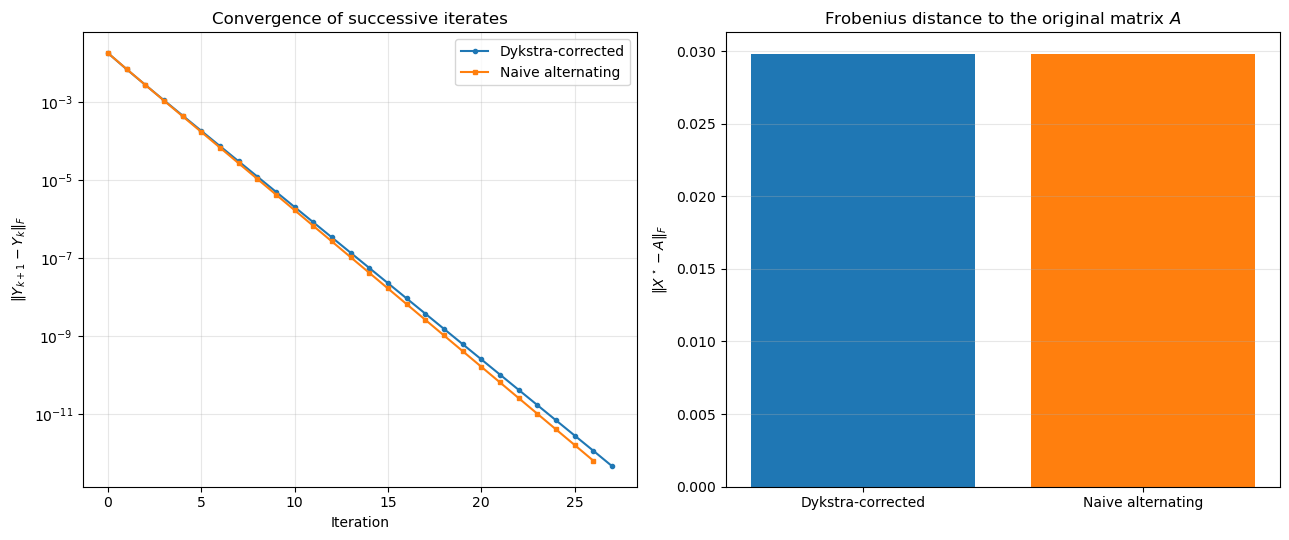

In [4]:
def naive_alternating_projection(A, tol=1e-10, max_iter=200):
    Y = A.copy()
    history = []
    for k in range(max_iter):
        X = project_psd(Y)
        Y_next = project_unit_diagonal(X)
        diff = np.linalg.norm(Y_next - Y, ord='fro')
        history.append(diff)
        Y = Y_next
        if diff < tol:
            break
    return 0.5 * (Y + Y.T), np.array(history), k + 1


X_naive, history_naive, n_iter_naive = naive_alternating_projection(A, tol=1e-12, max_iter=200)

dist_dykstra = np.linalg.norm(X_star - A, ord='fro')
dist_naive = np.linalg.norm(X_naive - A, ord='fro')

print(f"Dykstra-corrected: converged in {n_iter} iters, ||X_dykstra - A||_F = {dist_dykstra:.8f}")
print(f"Naive alternating: converged in {n_iter_naive} iters, ||X_naive   - A||_F = {dist_naive:.8f}")
print(f"\nNaive solution is farther from A by a factor of {dist_naive / dist_dykstra:.4f}x")
print("(both are PSD with unit diagonal -- the naive scheme is feasible but not Frobenius-optimal)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].semilogy(history, marker='o', markersize=3, label='Dykstra-corrected')
axes[0].semilogy(history_naive, marker='s', markersize=3, label='Naive alternating')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel(r'$\|Y_{k+1} - Y_k\|_F$')
axes[0].set_title('Convergence of successive iterates')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

methods = ['Dykstra-corrected', 'Naive alternating']
dists = [dist_dykstra, dist_naive]
axes[1].bar(methods, dists, color=['tab:blue', 'tab:orange'])
axes[1].set_ylabel(r'$\|X^\star - A\|_F$')
axes[1].set_title('Frobenius distance to the original matrix $A$')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('nearest_correlation_matrix_convergence.png', dpi=110)
plt.show()


## Notes

Both algorithms converge to a feasible point (a valid correlation matrix), and for this test case
the two feasible points are close: the naive scheme lands only a fraction of a percent farther
from $A$ than the Dykstra-corrected solution, and in fact reaches feasibility in slightly fewer
iterations. This is worth stating honestly rather than dressed up as a dramatic gap — it reflects
that for a "nearly PSD" correlation-repair problem like this one (a handful of bad pairwise
estimates and stress overrides against an otherwise consistent covariance structure), the two
projection targets are numerically close, and naive alternating projection lands near the true
optimum in this instance.

What Dykstra's correction actually buys is not "the naive answer is always much worse" but a
**certificate**: Boyle & Dykstra (1986) prove convergence to the *exact* Frobenius projection onto
$\mathcal S\cap\mathcal U$ for any two closed convex sets, unconditionally. Plain alternating
projection carries no such guarantee — it is only known to converge to *some* point of
$\mathcal S\cap\mathcal U$, and for a differently structured $A$ (more deeply indefinite, or with
degenerate/repeated eigenvalue structure that makes the PSD projection step non-unique) the two
fixed points can separate much further than they do here. Relying on the naive scheme means
relying on an empirical closeness that held for this $A$ but was never proven to hold in general;
the Dykstra-corrected result is the one that is Frobenius-optimal by construction, independent of
which particular indefinite matrix is fed in.

The output $X^\star$ is verified to be a genuine correlation matrix — symmetric, unit diagonal,
minimum eigenvalue non-negative to solver tolerance — and is therefore safe to feed into any
downstream routine (a Cholesky factor for correlated Monte Carlo sampling, a factor-model risk
decomposition) that requires positive semidefiniteness, which the risk desk's raw override matrix
$A$ was not.